# Lecture 4: Exploratory Data Analysis
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Conduct a structured EDA on a real dataset
2. Handle missing values and outliers
3. Analyse distributions and relationships
4. Generate insights to guide modelling decisions

In [1]:
# Install if running on Colab: !pip install -q pandas matplotlib seaborn scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
print('Ready.')

Ready.


## 4.1 Loading a Real Dataset

We use the Student Performance dataset from UCI ML Repository.

In [2]:
# Download UCI Student Performance dataset
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
import urllib.request, zipfile, io
try:
    response = urllib.request.urlopen(url, timeout=10)
    zf = zipfile.ZipFile(io.BytesIO(response.read()))
    df = pd.read_csv(zf.open('student-mat.csv'), sep=';')
    print('Dataset downloaded successfully.')
except Exception:
    print('Download failed. Generating synthetic equivalent...')
    np.random.seed(42)
    n = 395
    df = pd.DataFrame({
        'age': np.random.randint(15, 22, n),
        'studytime': np.random.randint(1, 5, n),
        'absences': np.random.poisson(4, n),
        'G1': np.random.randint(5, 19, n),
        'G2': np.random.randint(5, 19, n),
        'G3': np.random.randint(0, 20, n),
        'sex': np.random.choice(['M', 'F'], n),
        'address': np.random.choice(['U', 'R'], n),
        'Medu': np.random.randint(0, 5, n),
        'failures': np.random.randint(0, 4, n)
    })
    # Introduce realistic missing values
    for col in ['G1', 'absences']:
        df.loc[df.sample(frac=0.05).index, col] = np.nan
    print('Synthetic dataset created.')

print(f'Shape: {df.shape}')

Dataset downloaded successfully.
Shape: (395, 33)


In [3]:
# Step 1: Basic structure
print('=== Dataset Info ===')
df.info()
print('\n=== First 5 rows ===')
df.head()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    o

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
# Step 2: Summary statistics
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [5]:
# Step 3: Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})[missing > 0])

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


## 4.2 Handling Missing Values

In [7]:
# Impute numerical columns with median
num_cols = df.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])
print('After imputation:')
print(df.isnull().sum().sum(), 'missing values remaining')

After imputation:
0 missing values remaining


## 4.3 Distribution Analysis

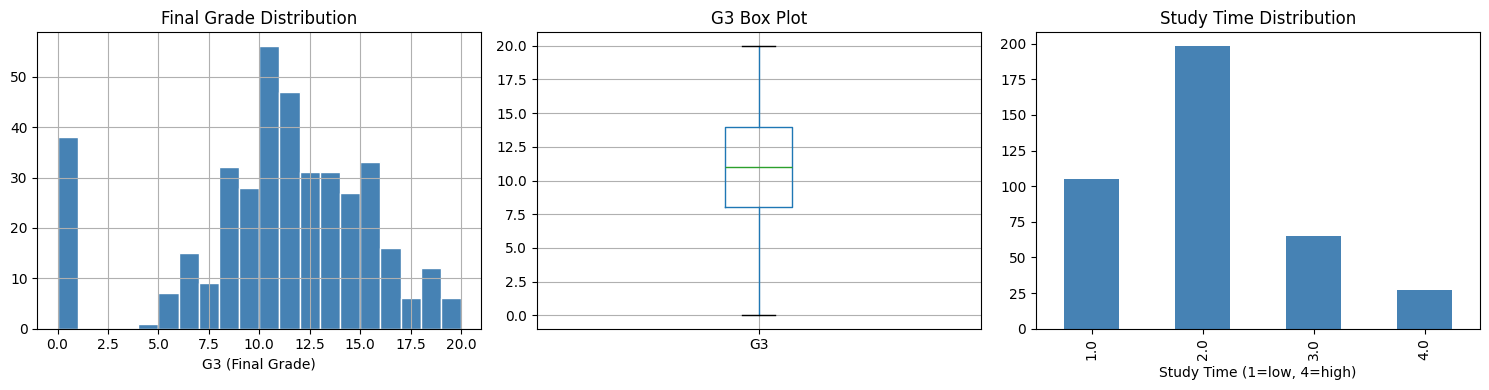

In [8]:
# Target variable: G3 (final grade)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df['G3'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Final Grade Distribution')
axes[0].set_xlabel('G3 (Final Grade)')

# Box plot
df.boxplot(column='G3', ax=axes[1])
axes[1].set_title('G3 Box Plot')

# Study time
df['studytime'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Study Time Distribution')
axes[2].set_xlabel('Study Time (1=low, 4=high)')

plt.tight_layout()
plt.show()

## 4.4 Outlier Detection (IQR Method)

In [9]:
col = 'absences'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df[col] < lower) | (df[col] > upper)]
print(f'Outlier bounds for "{col}": lower={lower:.1f}, upper={upper:.1f}')
print(f'Number of outliers: {len(outliers)}')
print(f'Max absences in dataset: {df[col].max():.0f}')

Outlier bounds for "absences": lower=-12.0, upper=20.0
Number of outliers: 15
Max absences in dataset: 75


## 4.5 Relationship Analysis

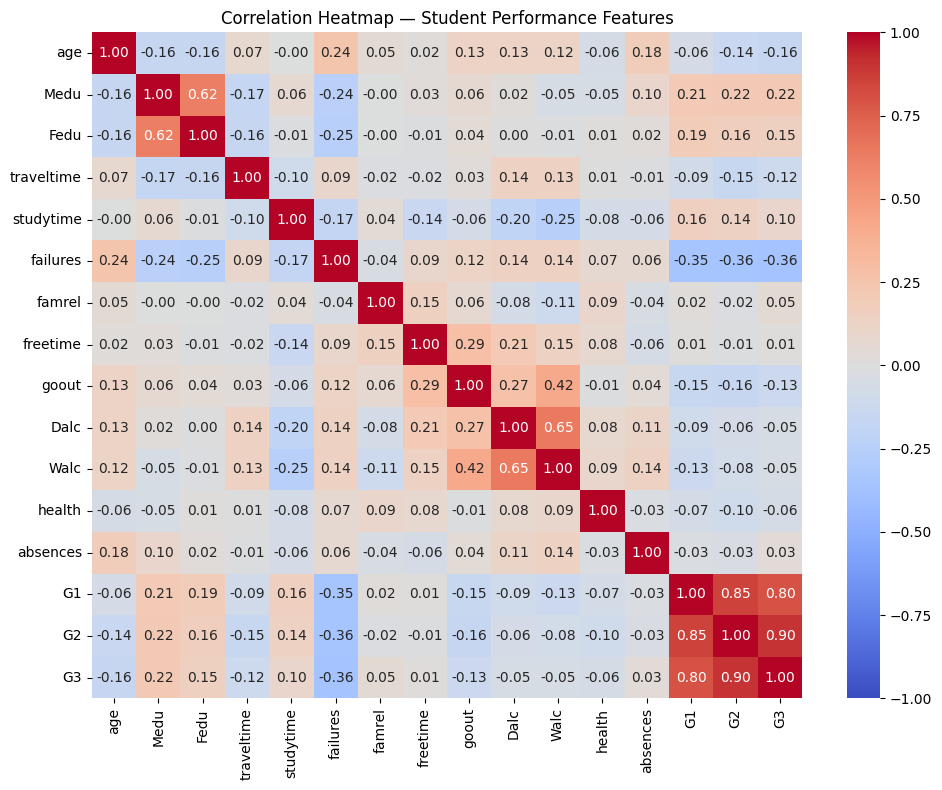

In [10]:
num_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Student Performance Features')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2463/746463090.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='G3', ax=axes[1], palette='Set2')


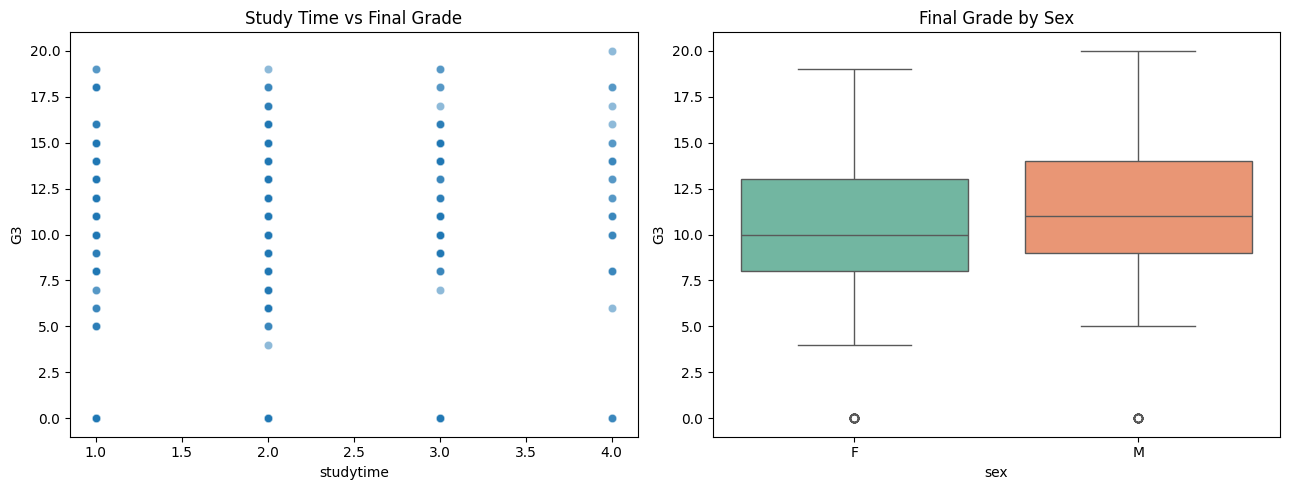

In [11]:
# Scatter matrix for grade variables
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=df, x='studytime', y='G3', alpha=0.5, ax=axes[0])
axes[0].set_title('Study Time vs Final Grade')
if 'sex' in df.columns:
    sns.boxplot(data=df, x='sex', y='G3', ax=axes[1], palette='Set2')
    axes[1].set_title('Final Grade by Sex')
plt.tight_layout()
plt.show()

### Exercise

Using the student performance DataFrame `df`:

1. Create a new binary column `passed` where G3 >= 10.
2. Calculate the pass rate overall and by sex.
3. Plot a bar chart showing mean G3 by study time level.
4. Identify the top 3 features most correlated with G3 using the correlation matrix.

Overall Pass Rate: 67.09%

Pass Rate by Sex:
sex
F    63.942308
M    70.588235
Name: passed, dtype: float64


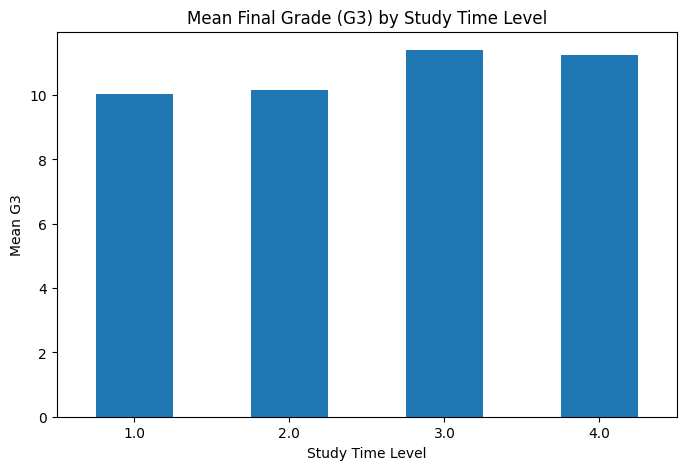


Top 3 Features Most Correlated with G3:
G2        0.904868
G1        0.801468
passed    0.770042
Name: G3, dtype: float64


In [12]:
# Your code here
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a new binary column 'passed'
df['passed'] = (df['G3'] >= 10).astype(int)

# 2. Calculate pass rate overall
overall_pass_rate = df['passed'].mean() * 100
print(f"Overall Pass Rate: {overall_pass_rate:.2f}%")

# Pass rate by sex
pass_rate_by_sex = df.groupby('sex')['passed'].mean() * 100
print("\nPass Rate by Sex:")
print(pass_rate_by_sex)

# 3. Plot a bar chart showing mean G3 by study time level
mean_g3_by_studytime = df.groupby('studytime')['G3'].mean()

plt.figure(figsize=(8, 5))
mean_g3_by_studytime.plot(kind='bar')
plt.title('Mean Final Grade (G3) by Study Time Level')
plt.xlabel('Study Time Level')
plt.ylabel('Mean G3')
plt.xticks(rotation=0)
plt.show()

# 4. Identify the top 3 features most correlated with G3

# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Correlations with G3
g3_corr = corr_matrix['G3'].drop('G3')

# Top 3 correlated features
top_3_features = g3_corr.abs().sort_values(ascending=False).head(3)

print("\nTop 3 Features Most Correlated with G3:")
print(top_3_features)


---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*